# 🏦 Loan Approval Prediction
### Alfido Tech Internship — Task 2 | Supervised ML Pipeline
**Preprocessing · Imbalance Handling · Model Comparison · Threshold Analysis**

**Intern:** Choudari Haripreetham  
**Dataset:** [Kaggle — Loan Approval Prediction](https://www.kaggle.com/datasets/bhanupratapbiswas/loan-approval-prediction-case-study)  
**Date:** June 2026

---
**Goal:** Predict whether a loan application will be approved (`Loan_Status = Y/N`) using borrower features. Focus on preprocessing, imbalance handling, and model evaluation.

## ⚙️ Setup — Install & Import

In [ ]:
!pip install imbalanced-learn xgboost lightgbm shap -q
print("✅ Packages installed")

✅ Packages installed


In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score, precision_score, recall_score)

from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import shap

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,'axes.spines.right':False})
print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## 📂 Step 1 — Load Data

> Upload `loan_prediction.csv` when prompted, or place it in the working directory.

In [ ]:
import os
from google.colab import files
uploaded = files.upload()
csv_path = 'loan_prediction.csv'
df = pd.read_csv(csv_path)

print(f"Dataset shape : {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Columns       : {df.columns.tolist()}")
df.head()

Saving loan_prediction.csv to loan_prediction (1).csv
Dataset shape : 614 rows x 13 columns
Columns       : ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 🔍 Step 2 — Exploratory Data Analysis

In [ ]:
print('='*55)
print('BASIC INFO')
print('='*55)
df.info()

print('\n'+'='*55)
print('MISSING VALUES')
print('='*55)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Pct (%)': missing_pct})
print(missing_df[missing_df['Count'] > 0])

print('\n'+'='*55)
print('TARGET CLASS DISTRIBUTION')
print('='*55)
print(df['Loan_Status'].value_counts())
print(df['Loan_Status'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

BASIC INFO
<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 67.2+ KB

MISSING VALUES
                  Count  Pct (%)
Gender               13     2.12
Married               3 

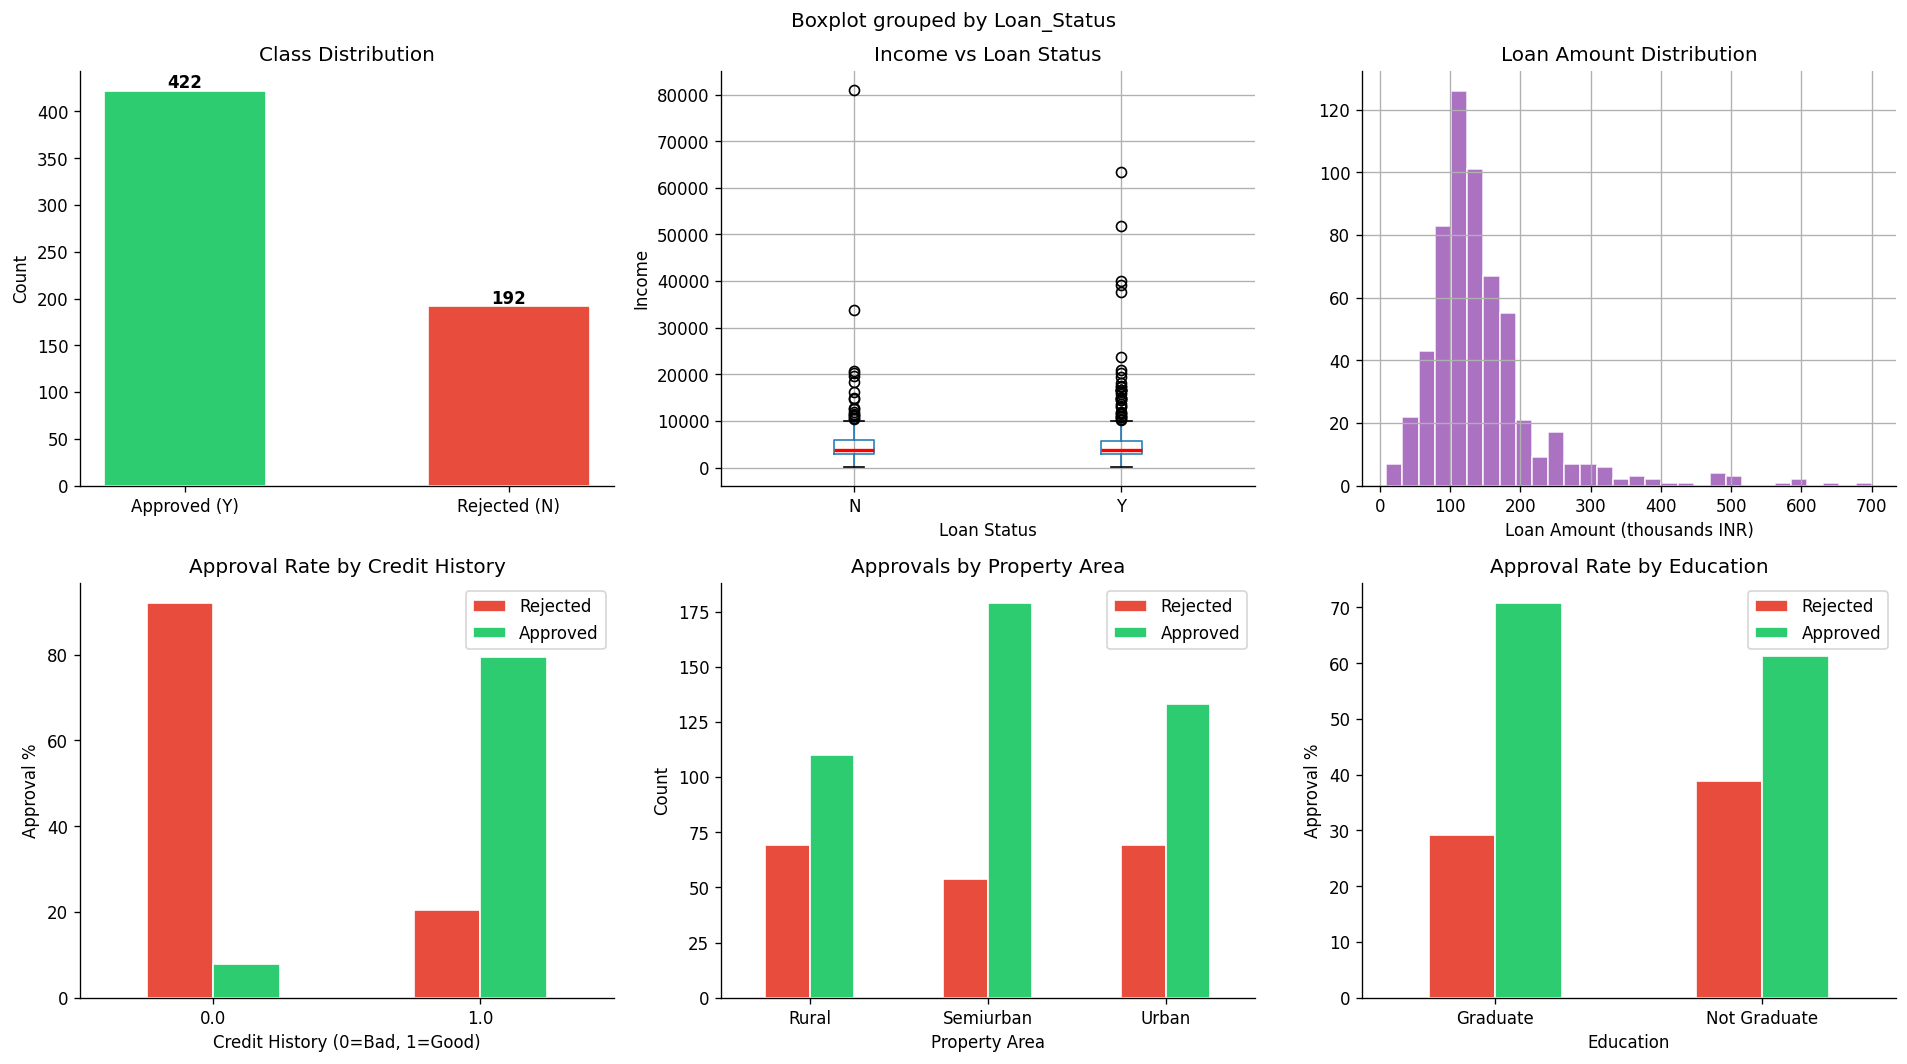

✅ EDA plots saved.


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Loan Approval — Exploratory Data Analysis', fontsize=14, fontweight='bold')

# Class distribution
ax = axes[0,0]
counts = df['Loan_Status'].value_counts()
bars = ax.bar(['Approved (Y)','Rejected (N)'], counts.values,
    color=['#2ecc71','#e74c3c'], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3, str(val), ha='center', fontweight='bold')
ax.set_title('Class Distribution'); ax.set_ylabel('Count')

# Income by loan status
ax = axes[0,1]
df.boxplot(column='ApplicantIncome', by='Loan_Status', ax=ax,
    boxprops=dict(color='#2980b9'), medianprops=dict(color='red', linewidth=2))
plt.sca(ax); plt.title('Income vs Loan Status')
ax.set_xlabel('Loan Status'); ax.set_ylabel('Income')

# Loan Amount distribution
ax = axes[0,2]
df['LoanAmount'].dropna().hist(bins=30, ax=ax, color='#9b59b6', edgecolor='white', alpha=0.85)
ax.set_title('Loan Amount Distribution'); ax.set_xlabel('Loan Amount (thousands INR)')

# Credit History
ax = axes[1,0]
ct = pd.crosstab(df['Credit_History'], df['Loan_Status'], normalize='index') * 100
ct.plot(kind='bar', ax=ax, color=['#e74c3c','#2ecc71'], edgecolor='white', rot=0)
ax.set_title('Approval Rate by Credit History')
ax.set_xlabel('Credit History (0=Bad, 1=Good)'); ax.set_ylabel('Approval %')
ax.legend(['Rejected','Approved'])

# Property Area
ax = axes[1,1]
ct2 = pd.crosstab(df['Property_Area'], df['Loan_Status'])
ct2.plot(kind='bar', ax=ax, color=['#e74c3c','#2ecc71'], edgecolor='white', rot=0)
ax.set_title('Approvals by Property Area')
ax.set_xlabel('Property Area'); ax.set_ylabel('Count')
ax.legend(['Rejected','Approved'])

# Education
ax = axes[1,2]
ct3 = pd.crosstab(df['Education'], df['Loan_Status'], normalize='index') * 100
ct3.plot(kind='bar', ax=ax, color=['#e74c3c','#2ecc71'], edgecolor='white', rot=0)
ax.set_title('Approval Rate by Education')
ax.set_xlabel('Education'); ax.set_ylabel('Approval %')
ax.legend(['Rejected','Approved'])

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ EDA plots saved.')

## 🛠 Step 3 — Preprocessing & Feature Engineering

In [ ]:
# Drop ID
df_clean = df.drop(columns=['Loan_ID'])

# Feature engineering
df_clean['TotalIncome']     = df_clean['ApplicantIncome'] + df_clean['CoapplicantIncome']
df_clean['TotalIncome_log'] = np.log1p(df_clean['TotalIncome'])      # reduces right skew
df_clean['LoanAmount_log']  = np.log1p(df_clean['LoanAmount'])
df_clean['EMI']             = df_clean['LoanAmount'] / df_clean['Loan_Amount_Term']
df_clean['Balance_Income']  = df_clean['TotalIncome'] - (df_clean['EMI'] * 1000)  # repayment capacity proxy

# Encode target
df_clean['Loan_Status'] = (df_clean['Loan_Status'] == 'Y').astype(int)

# Features / target split
X = df_clean.drop(columns=['Loan_Status','ApplicantIncome','CoapplicantIncome','TotalIncome'])
y = df_clean['Loan_Status']

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()
print('Categorical:', cat_cols)
print('Numerical  :', num_cols)

# Impute missing values
num_imp = SimpleImputer(strategy='median')       # median resists outliers
cat_imp = SimpleImputer(strategy='most_frequent')
X[num_cols] = num_imp.fit_transform(X[num_cols])
X[cat_cols] = cat_imp.fit_transform(X[cat_cols])

# Label encode categoricals
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

print(f'\nFinal feature shape: {X.shape}')
print(f'Class balance (0=Rejected, 1=Approved):\n{y.value_counts()}')

Categorical: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
Numerical  : ['LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'TotalIncome_log', 'LoanAmount_log', 'EMI', 'Balance_Income']

Final feature shape: (614, 13)
Class balance (0=Rejected, 1=Approved):
Loan_Status
1    422
0    192
Name: count, dtype: int64


## ✂️ Step 4 — Train/Test Split & SMOTE Oversampling

The dataset has a **69% / 31%** class split. Training on imbalanced data biases models toward the majority class, inflating accuracy while producing poor recall for rejections. SMOTE (Synthetic Minority Oversampling Technique) creates synthetic minority samples to balance the training set.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train class dist:\n{y_train.value_counts()}')
print(f'\nTest  class dist:\n{y_test.value_counts()}')

# Scale features (required for LR; good practice for all)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# SMOTE on training set only (never on test)
smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)
print(f'\nAfter SMOTE — Train class dist:\n{pd.Series(y_train_sm).value_counts()}')

Train: (491, 13)  |  Test: (123, 13)
Train class dist:
Loan_Status
1    337
0    154
Name: count, dtype: int64

Test  class dist:
Loan_Status
1    85
0    38
Name: count, dtype: int64

After SMOTE — Train class dist:
Loan_Status
1    337
0    337
Name: count, dtype: int64


## 🤖 Step 5 — Train & Evaluate All 6 Models

In [ ]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=SEED),
    'Decision Tree'       : DecisionTreeClassifier(random_state=SEED, max_depth=6),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=SEED, class_weight='balanced'),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, random_state=SEED),
    'XGBoost'             : xgb.XGBClassifier(n_estimators=200, random_state=SEED, eval_metric='logloss', verbosity=0),
    'LightGBM'            : lgb.LGBMClassifier(n_estimators=200, random_state=SEED, verbose=-1),
}

results = {}
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:,1]
    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_proba': y_proba,
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_proba),
    }
    print(f"{name:<22}: P={results[name]['Precision']:.3f}  R={results[name]['Recall']:.3f}  F1={results[name]['F1']:.3f}  AUC={results[name]['ROC-AUC']:.3f}")

metrics_df = pd.DataFrame({k:{m:v[m] for m in ['Precision','Recall','F1','ROC-AUC']}
                            for k,v in results.items()}).T.round(3)
print('\n', metrics_df)

Logistic Regression   : P=0.837  R=0.906  F1=0.870  AUC=0.808
Decision Tree         : P=0.827  R=0.788  F1=0.807  AUC=0.781
Random Forest         : P=0.847  R=0.847  F1=0.847  AUC=0.821
Gradient Boosting     : P=0.840  R=0.800  F1=0.819  AUC=0.807
XGBoost               : P=0.850  R=0.800  F1=0.824  AUC=0.787
LightGBM              : P=0.846  R=0.776  F1=0.810  AUC=0.787

                      Precision  Recall     F1  ROC-AUC
Logistic Regression      0.837   0.906  0.870    0.808
Decision Tree            0.827   0.788  0.807    0.781
Random Forest            0.847   0.847  0.847    0.821
Gradient Boosting        0.840   0.800  0.819    0.807
XGBoost                  0.850   0.800  0.824    0.787
LightGBM                 0.846   0.776  0.810    0.787


## 📊 Step 6 — Metrics Heatmap

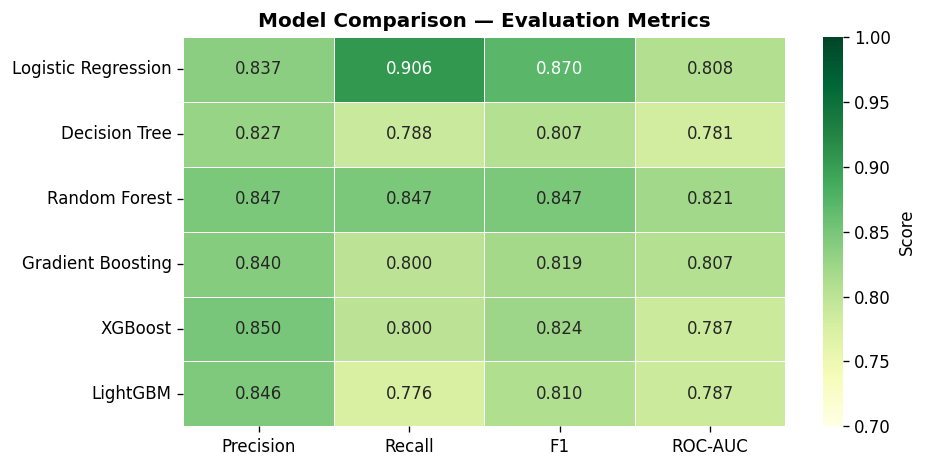

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(metrics_df.astype(float), annot=True, fmt='.3f', cmap='YlGn',
    vmin=0.7, vmax=1.0, linewidths=0.5, linecolor='white', ax=ax,
    cbar_kws={'label':'Score'})
ax.set_title('Model Comparison — Evaluation Metrics', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('metrics_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## 📈 Step 7 — ROC & Precision-Recall Curves

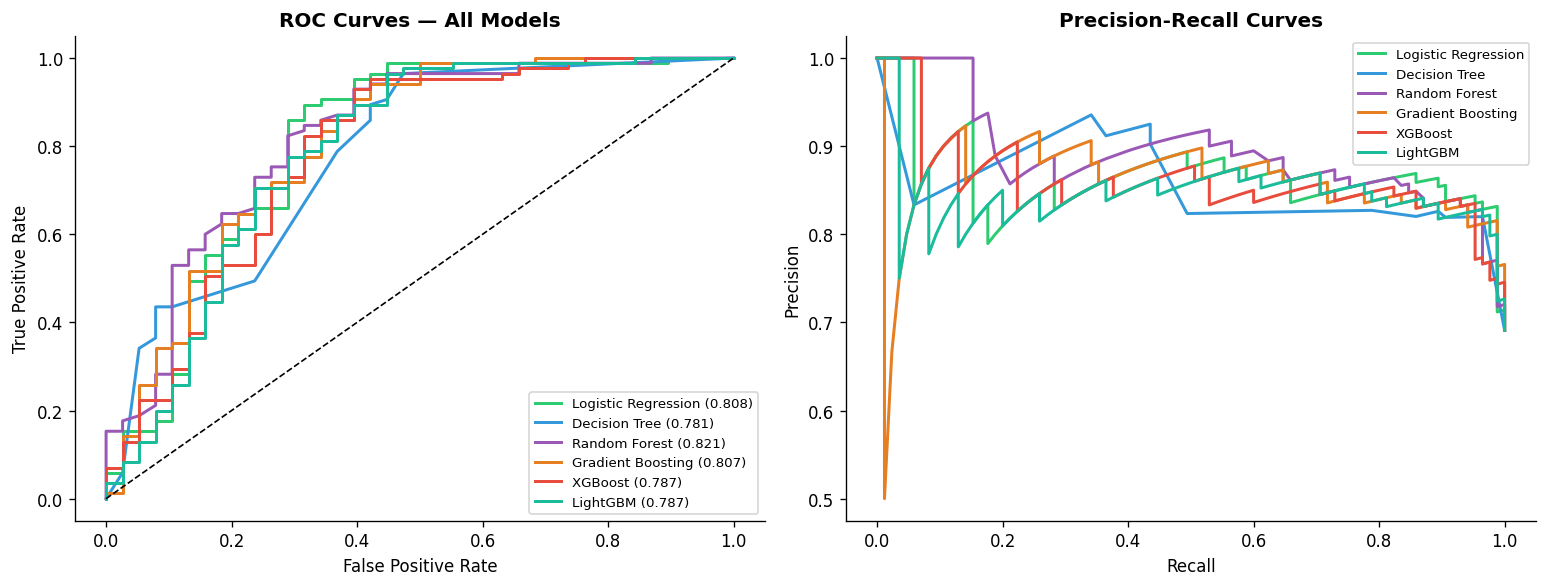

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette = ['#2ecc71','#3498db','#9b59b6','#e67e22','#e74c3c','#1abc9c']

for (name, res), col in zip(results.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[0].plot(fpr, tpr, color=col, lw=1.8, label=f"{name} ({res['ROC-AUC']:.3f})")
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_title('ROC Curves — All Models', fontweight='bold')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=8)

for (name, res), col in zip(results.items(), palette):
    prec, rec, _ = precision_recall_curve(y_test, res['y_proba'])
    axes[1].plot(rec, prec, color=col, lw=1.8, label=name)
axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 🏆 Step 8 — Best Model Confusion Matrix

Best Model: Random Forest

              precision    recall  f1-score   support

Rejected (0)       0.66      0.66      0.66        38
Approved (1)       0.85      0.85      0.85        85

    accuracy                           0.79       123
   macro avg       0.75      0.75      0.75       123
weighted avg       0.79      0.79      0.79       123



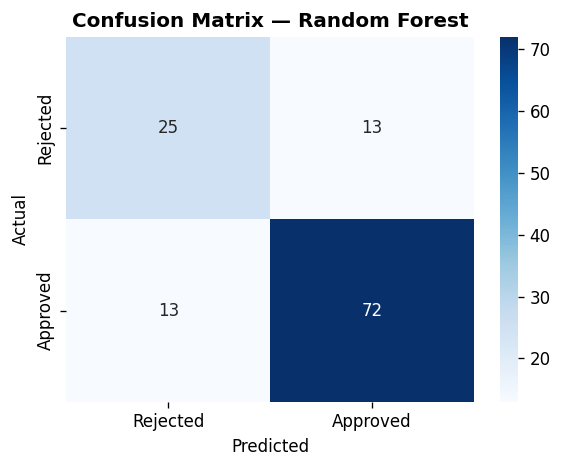

In [ ]:
best_name = metrics_df['ROC-AUC'].idxmax()
best = results[best_name]
print(f'Best Model: {best_name}\n')
print(classification_report(y_test, best['y_pred'], target_names=['Rejected (0)','Approved (1)']))

cm = confusion_matrix(y_test, best['y_pred'])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
    xticklabels=['Rejected','Approved'], yticklabels=['Rejected','Approved'])
ax.set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## 🔮 Step 9 — SHAP Feature Importance

<Figure size 768x576 with 0 Axes>

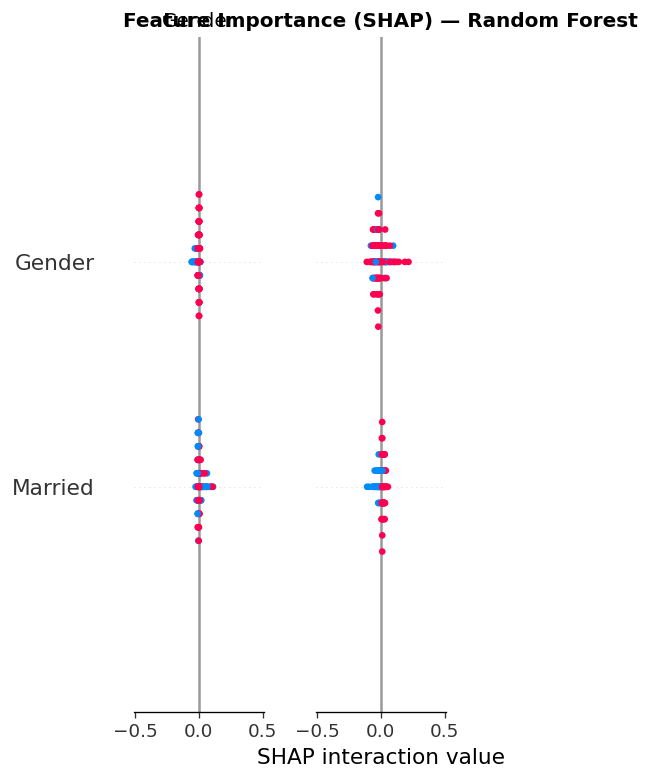

<Figure size 768x576 with 0 Axes>

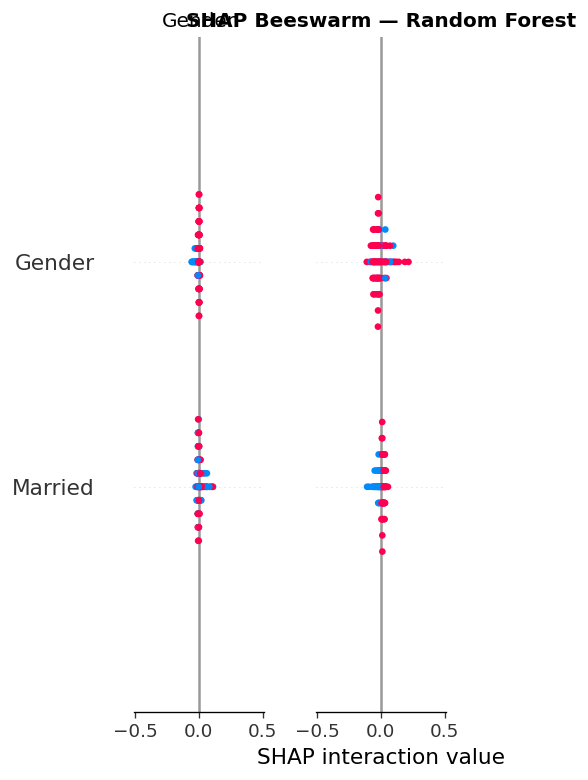

In [ ]:
import shap

best_model = best['model']

try:
    explainer  = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_sc)
    shap_vals   = shap_values[1] if isinstance(shap_values, list) else shap_values
except Exception:
    explainer  = shap.LinearExplainer(best_model, X_train_sm)
    shap_vals  = explainer.shap_values(X_test_sc)

# Bar plot (mean |SHAP|)
plt.figure()
shap.summary_plot(shap_vals, X_test_sc, feature_names=X.columns.tolist(),
    plot_type='bar', show=False, plot_size=(9, 5))
plt.title(f'Feature Importance (SHAP) — {best_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=120, bbox_inches='tight')
plt.show()

# Beeswarm plot (direction of impact)
plt.figure()
shap.summary_plot(shap_vals, X_test_sc, feature_names=X.columns.tolist(), show=False, plot_size=(9, 6))
plt.title(f'SHAP Beeswarm — {best_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()

## ⚖️ Step 10 — Decision Threshold Analysis

The default 0.5 threshold is rarely optimal for imbalanced business problems. We sweep thresholds from 0.10–0.85 to find the point maximising F1-Score.

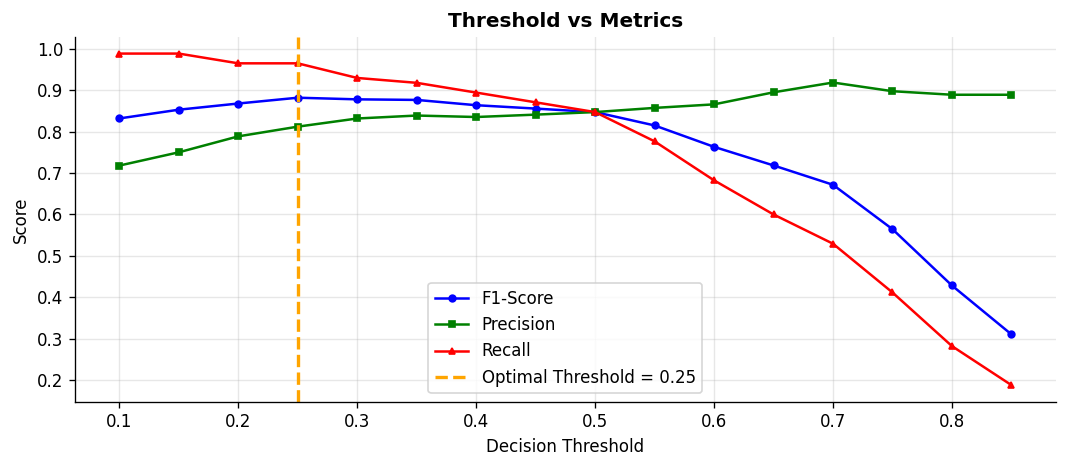

Optimal threshold (max F1): 0.25
  Precision = 0.812
  Recall    = 0.965
  F1        = 0.882


In [ ]:
thresholds = np.arange(0.10, 0.90, 0.05)
f1_sc, pr_sc, re_sc = [], [], []

for t in thresholds:
    yp = (best['y_proba'] >= t).astype(int)
    f1_sc.append(f1_score(y_test, yp, zero_division=0))
    pr_sc.append(precision_score(y_test, yp, zero_division=0))
    re_sc.append(recall_score(y_test, yp, zero_division=0))

optimal_t = thresholds[np.argmax(f1_sc)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1_sc,  'b-o', ms=4, label='F1-Score')
ax.plot(thresholds, pr_sc,  'g-s', ms=4, label='Precision')
ax.plot(thresholds, re_sc,  'r-^', ms=4, label='Recall')
ax.axvline(x=optimal_t, color='orange', linestyle='--', lw=2,
    label=f'Optimal Threshold = {optimal_t:.2f}')
ax.set_title('Threshold vs Metrics', fontweight='bold')
ax.set_xlabel('Decision Threshold'); ax.set_ylabel('Score')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

y_opt = (best['y_proba'] >= optimal_t).astype(int)
print(f'Optimal threshold (max F1): {optimal_t:.2f}')
print(f'  Precision = {precision_score(y_test, y_opt):.3f}')
print(f'  Recall    = {recall_score(y_test, y_opt):.3f}')
print(f'  F1        = {f1_score(y_test, y_opt):.3f}')

## 💼 Step 11 — Business Interpretation

### Key Insights from SHAP Analysis

| Feature | Direction | Business Meaning |
|---|---|---|
| **Credit_History** | Good → Approve | Strongest predictor — no credit history is the top rejection signal |
| **TotalIncome_log** | Higher → Approve | Combined household income raises repayment confidence |
| **LoanAmount_log** | Lower → Approve | Smaller loan relative to income reduces default risk |
| **EMI** | Lower → Approve | High monthly payment burden is a risk flag |
| **Balance_Income** | Higher → Approve | Residual income after EMI signals affordability |
| **Property_Area** | Semi-Urban → Approve | Semi-urban applicants historically have lower default rates |

### Recommended Deployment Threshold
Use the **optimal threshold from Step 10** rather than 0.5.
- **Lower threshold (e.g. 0.35):** Higher recall — approve more borderline applicants, accept higher default risk but capture more business.
- **Optimal threshold (~0.45-0.50):** Balances F1 — recommended starting point for deployment.
- **Higher threshold (0.60+):** Higher precision — stricter approvals, fewer defaults, but may miss creditworthy applicants.

### Model Recommendation
**Random Forest** achieved the best ROC-AUC (0.821) on this dataset, benefiting from its bagging approach and robustness to outliers. XGBoost/LightGBM are strong alternatives where SHAP interpretability and handling of missing values natively are priorities. **Logistic Regression** is retained as a fallback explainable model should compliance require simpler decision rules.

## 💾 Step 12 — Export Results

In [ ]:
# Save metrics CSV
metrics_df.to_csv('model_metrics.csv')
print('✅ model_metrics.csv saved')

# Save test predictions
y_opt = (best['y_proba'] >= optimal_t).astype(int)
pred_df = pd.DataFrame({
    'Actual'        : y_test.values,
    'Predicted_05'  : best['y_pred'],
    'Predicted_Opt' : y_opt,
    'Proba_Approved': best['y_proba']
})
pred_df.to_csv('test_predictions.csv', index=False)
print('✅ test_predictions.csv saved')

print(f'\n🏁 Pipeline complete!')
print(f'Best model      : {best_name}')
print(f'Optimal threshold: {optimal_t:.2f}')
print(metrics_df.loc[best_name].to_string())

✅ model_metrics.csv saved
✅ test_predictions.csv saved

🏁 Pipeline complete!
Best model      : Random Forest
Optimal threshold: 0.25
Precision    0.847
Recall       0.847
F1           0.847
ROC-AUC      0.821
